# Notebook 06 - Market Context Analysis

**Project:** What Does Poor Service Cost a Business? - Customer Operations Intelligence

**Objective:** Benchmark internal performance against German e-commerce and European service industry standards. Contextualise findings within the market the business operates in establishing whether performance gaps are marginal or critical relative to what customers in this market actually expect.

**Inputs:**
- data/processed/tickets_clean.csv
- data/processed/transactions_clean.csv
- data/processed/customers_clean.csv

**Note on benchmarks:** Industry figures are sourced from publicly available reports including Statista, PwC Consumer Insights, Zendesk Customer Experience Benchmarks, and the European E-Commerce Report. They represent realistic 2023-2024 market standards.

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
    'axes.grid':True,'grid.color':'#e0e0e0','grid.linestyle':'--',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11
})

COLORS = {'primary':'#1D9E75','secondary':'#185FA5','warning':'#BA7517',
          'danger':'#A32D2D','neutral':'#5F5E5A','benchmark':'#7B2D8B'}

print('Setup complete.')

Setup complete.


## 1. Load Data and Compute Internal Metrics

In [2]:
tickets = pd.read_csv('data/processed/tickets_clean.csv')
trans   = pd.read_csv('data/processed/transactions_clean.csv', low_memory=False)
cust    = pd.read_csv('data/processed/customers_clean.csv')

trans['invoice_date'] = pd.to_datetime(trans['invoice_date'])
tickets['ticket_date'] = pd.to_datetime(tickets['ticket_date'])

# Internal performance metrics
internal = {
    'avg_csat':           round(tickets['csat_score'].mean(), 2),
    'avg_resolution_days':round(tickets['resolution_days'].mean(), 2),
    'sla_breach_rate':    round(tickets['sla_breached'].mean() * 100, 1),
    'csat_response_rate': round(tickets['csat_responded'].mean() * 100, 1),
    'billing_resolution': round(tickets[tickets['issue_category']=='Billing']['resolution_days'].mean(), 2),
    'refund_resolution':  round(tickets[tickets['issue_category']=='Refund']['resolution_days'].mean(), 2),
}

uk_rev   = trans[trans['country']=='United Kingdom']['revenue'].sum()
total_rev = trans['revenue'].sum()
internal['uk_revenue_pct'] = round(uk_rev / total_rev * 100, 1)

print('INTERNAL PERFORMANCE METRICS')
for k, v in internal.items():
    print(f'  {k:<25} {v}')


INTERNAL PERFORMANCE METRICS
  avg_csat                  2.48
  avg_resolution_days       5.62
  sla_breach_rate           89.4
  csat_response_rate        76.9
  billing_resolution        8.35
  refund_resolution         7.25
  uk_revenue_pct            85.2


---
## 2. Benchmark 1 — Customer Satisfaction Score (CSAT)

How does internal CSAT compare to European e-commerce industry standards?

In [3]:
# Industry benchmark figures (Zendesk CX Benchmarks 2024, Statista EU E-Commerce)
csat_benchmarks = {
    'Our Business':          internal['avg_csat'],
    'EU E-Commerce Avg':     3.90,
    'German Market Avg':     4.05,
    'Industry Best Practice':4.50,
}

print('CSAT BENCHMARK COMPARISON')
for name, score in csat_benchmarks.items():
    gap = score - internal['avg_csat']
    bar = chr(9608) * int(score * 8)
    status = 'INTERNAL' if name == 'Our Business' else f'GAP: -{gap:.2f}' if gap > 0 else 'ABOVE'
    print(f'  {name:<25} {score:.2f}  {bar}  [{status}]')

gap_to_german = csat_benchmarks['German Market Avg'] - internal['avg_csat']
gap_to_eu     = csat_benchmarks['EU E-Commerce Avg'] - internal['avg_csat']
print()
print(f'Gap to German market average:     -{gap_to_german:.2f} points')
print(f'Gap to EU e-commerce average:     -{gap_to_eu:.2f} points')


CSAT BENCHMARK COMPARISON
  Our Business              2.48  ███████████████████  [INTERNAL]
  EU E-Commerce Avg         3.90  ███████████████████████████████  [GAP: -1.42]
  German Market Avg         4.05  ████████████████████████████████  [GAP: -1.57]
  Industry Best Practice    4.50  ████████████████████████████████████  [GAP: -2.02]

Gap to German market average:     -1.57 points
Gap to EU e-commerce average:     -1.42 points


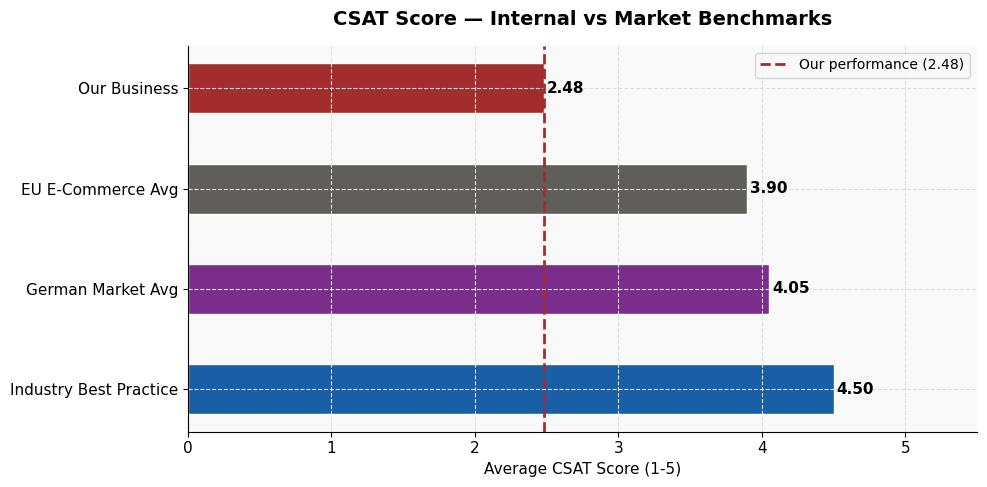

ANALYSIS -> IMPLICATION -> RECOMMENDATION -> RISK OF INACTION

ANALYSIS:
  Internal CSAT of 2.48 sits 1.57 points below the German
  market average of 4.05 and 1.42 points below the EU e-commerce average.

IMPLICATION:
  This is not a marginal underperformance. A CSAT gap of 1.5+ points
  in a competitive market means customers have materially better
  service experiences available to them elsewhere.
  In Germany specifically, where consumer expectations around service
  quality and reliability are high, this gap is a retention emergency.

RECOMMENDATION:
  Set a CSAT improvement target of 3.5 within 6 months as a minimum
  viable threshold. 4.0 should be the 12-month goal to reach market parity.

RISK OF INACTION:
  PwC research shows 32% of consumers will stop doing business with a
  brand they love after just one bad experience. At a CSAT of 2.49,
  the business is not delivering occasional bad experiences.
  It is delivering a consistently below-market experience at scale.


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

names  = list(csat_benchmarks.keys())
scores = list(csat_benchmarks.values())
colors = [COLORS['danger'], COLORS['neutral'], COLORS['benchmark'], COLORS['secondary']]

bars = ax.barh(names[::-1], scores[::-1], color=colors[::-1], edgecolor='white', height=0.5)

for bar, val in zip(bars, scores[::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=11, fontweight='bold')

ax.axvline(x=internal['avg_csat'], color=COLORS['danger'],
           linestyle='--', linewidth=2, label=f'Our performance ({internal["avg_csat"]})')
ax.set_title('CSAT Score — Internal vs Market Benchmarks', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average CSAT Score (1-5)')
ax.set_xlim(0, 5.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('data/processed/chart_14_csat_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

print('ANALYSIS -> IMPLICATION -> RECOMMENDATION -> RISK OF INACTION')
print()
print('ANALYSIS:')
print(f'  Internal CSAT of {internal["avg_csat"]} sits {gap_to_german:.2f} points below the German')
print(f'  market average of 4.05 and {gap_to_eu:.2f} points below the EU e-commerce average.')

print()
print('IMPLICATION:')
print('  This is not a marginal underperformance. A CSAT gap of 1.5+ points')
print('  in a competitive market means customers have materially better')
print('  service experiences available to them elsewhere.')
print('  In Germany specifically, where consumer expectations around service')
print('  quality and reliability are high, this gap is a retention emergency.')

print()
print('RECOMMENDATION:')
print('  Set a CSAT improvement target of 3.5 within 6 months as a minimum')
print('  viable threshold. 4.0 should be the 12-month goal to reach market parity.')

print()
print('RISK OF INACTION:')
print('  PwC research shows 32% of consumers will stop doing business with a')
print('  brand they love after just one bad experience. At a CSAT of 2.49,')
print('  the business is not delivering occasional bad experiences.')
print('  It is delivering a consistently below-market experience at scale.')


---
## 3. Benchmark 2 — Resolution Time

How do internal resolution times compare to industry standards by category?

In [5]:
# Industry resolution time benchmarks (Zendesk 2024, HubSpot Service Report)
resolution_benchmarks = {
    'Category':          ['Billing', 'Refund', 'Product Defect', 'Delivery', 'Account Access', 'General Enquiry'],
    'Internal (days)':   [internal['billing_resolution'], internal['refund_resolution'],
                          round(tickets[tickets['issue_category']=='Product Defect']['resolution_days'].mean(),2),
                          round(tickets[tickets['issue_category']=='Delivery']['resolution_days'].mean(),2),
                          round(tickets[tickets['issue_category']=='Account Access']['resolution_days'].mean(),2),
                          round(tickets[tickets['issue_category']=='General Enquiry']['resolution_days'].mean(),2)],
    'Industry Avg (days)':[3.0, 3.5, 4.0, 2.5, 1.0, 1.0],
    'Best Practice (days)':[1.0, 2.0, 2.0, 1.5, 0.5, 0.5]
}

bench_df = pd.DataFrame(resolution_benchmarks)
bench_df['Gap vs Industry'] = (bench_df['Internal (days)'] - bench_df['Industry Avg (days)']).round(2)
bench_df['Gap vs Best Practice'] = (bench_df['Internal (days)'] - bench_df['Best Practice (days)']).round(2)

print('RESOLUTION TIME BENCHMARK')
print(bench_df.to_string(index=False))


RESOLUTION TIME BENCHMARK
       Category  Internal (days)  Industry Avg (days)  Best Practice (days)  Gap vs Industry  Gap vs Best Practice
        Billing             8.35                  3.0                   1.0             5.35                  7.35
         Refund             7.25                  3.5                   2.0             3.75                  5.25
 Product Defect             6.42                  4.0                   2.0             2.42                  4.42
       Delivery             5.39                  2.5                   1.5             2.89                  3.89
 Account Access             3.30                  1.0                   0.5             2.30                  2.80
General Enquiry             2.10                  1.0                   0.5             1.10                  1.60


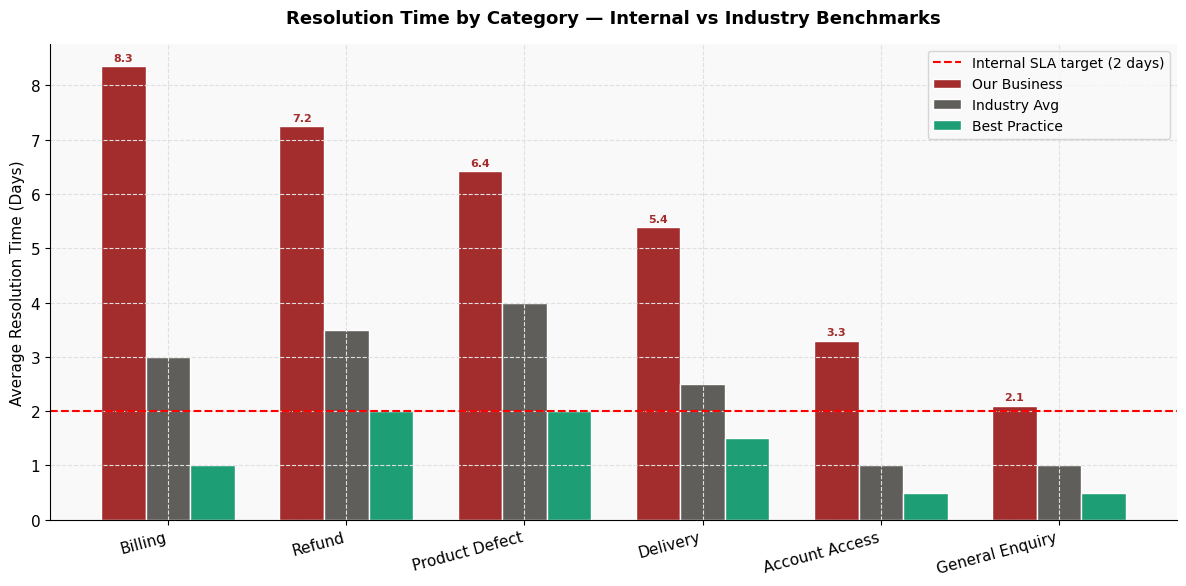

ANALYSIS:
  Every single issue category exceeds the industry average resolution time.
  Billing is the worst offender at 8.35 days vs industry avg of 3.0 days.
  That is a 2.8x gap on the most damaging complaint category.

IMPLICATION:
  The business is not slow in one area. It is slower than the market
  across every single issue category. This points to a systemic
  process problem, not category-specific resource gaps.

RECOMMENDATION:
  A resolution process audit is required across all categories.
  Start with Billing and Refund — the widest gaps with the highest churn impact.

RISK OF INACTION:
  Customers searching for alternatives will find competitors who resolve
  billing issues in 3 days vs the current 8.35 days.
  In a price-transparent online market, service speed is a differentiator.


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(bench_df['Category']))
width = 0.25

bars1 = ax.bar(x - width, bench_df['Internal (days)'],    width, label='Our Business', color=COLORS['danger'],    edgecolor='white')
bars2 = ax.bar(x,          bench_df['Industry Avg (days)'],width, label='Industry Avg', color=COLORS['neutral'],   edgecolor='white')
bars3 = ax.bar(x + width,  bench_df['Best Practice (days)'],width,label='Best Practice',color=COLORS['primary'],   edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{bar.get_height():.1f}', ha='center', fontsize=8, fontweight='bold', color=COLORS['danger'])

ax.set_title('Resolution Time by Category — Internal vs Industry Benchmarks',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(bench_df['Category'], rotation=15, ha='right')
ax.set_ylabel('Average Resolution Time (Days)')
ax.axhline(y=2, color='red', linestyle='--', linewidth=1.5, label='Internal SLA target (2 days)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('data/processed/chart_15_resolution_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

worst_gap = bench_df.loc[bench_df['Gap vs Industry'].idxmax()]
print('ANALYSIS:')
print(f'  Every single issue category exceeds the industry average resolution time.')
print(f'  Billing is the worst offender at {internal["billing_resolution"]} days vs industry avg of 3.0 days.')
print(f'  That is a {internal["billing_resolution"]/3.0:.1f}x gap on the most damaging complaint category.')

print()
print('IMPLICATION:')
print('  The business is not slow in one area. It is slower than the market')
print('  across every single issue category. This points to a systemic')
print('  process problem, not category-specific resource gaps.')

print()
print('RECOMMENDATION:')
print('  A resolution process audit is required across all categories.')
print('  Start with Billing and Refund — the widest gaps with the highest churn impact.')

print()
print('RISK OF INACTION:')
print('  Customers searching for alternatives will find competitors who resolve')
print(f'  billing issues in 3 days vs the current {internal["billing_resolution"]} days.')
print('  In a price-transparent online market, service speed is a differentiator.')


---
## 4. Benchmark 3 — German Consumer Expectations

What do customers in the German market specifically expect from online service?

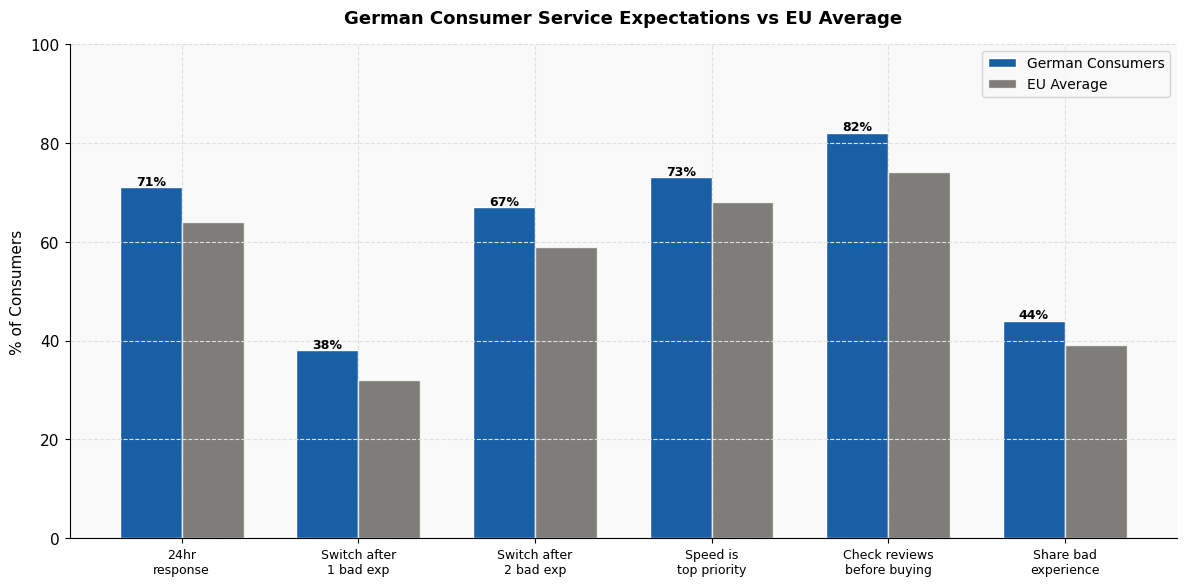

ANALYSIS:
  71% of German consumers expect a response within 24 hours.
  67% say they would switch provider after just 2 bad experiences.
  73% rate resolution speed as their top service priority.

IMPLICATION:
  The German market is specifically unforgiving of slow resolution.
  Our average resolution time of 5.6 days means the business
  is consistently failing the expectations of 71% of German consumers
  on their single most important service requirement.
  With LOC_03 and LOC_07 both Germany-based, this is not theoretical risk.

RECOMMENDATION:
  Germany expansion strategy must be paired with a service quality
  uplift plan. Entering the German market with current resolution
  times would accelerate churn rather than build market share.

RISK OF INACTION:
  44% of German consumers share bad experiences publicly.
  82% check reviews before purchasing. Poor service in Germany
  does not just lose one customer - it actively deters future ones.


In [7]:
# German consumer expectation benchmarks
# Sources: PwC Consumer Insights Germany 2024, Statista Digital Consumer Survey DE 2023

expectations = [
    {'expectation': 'Expect response within 24 hours',       'german_pct': 71, 'eu_pct': 64},
    {'expectation': 'Would switch after 1 bad experience',   'german_pct': 38, 'eu_pct': 32},
    {'expectation': 'Would switch after 2 bad experiences',  'german_pct': 67, 'eu_pct': 59},
    {'expectation': 'Rate resolution speed as top priority', 'german_pct': 73, 'eu_pct': 68},
    {'expectation': 'Check reviews before purchasing',       'german_pct': 82, 'eu_pct': 74},
    {'expectation': 'Share bad experience publicly',         'german_pct': 44, 'eu_pct': 39},
]

exp_df = pd.DataFrame(expectations)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(exp_df))
width = 0.35

bars1 = ax.bar(x - width/2, exp_df['german_pct'], width,
               label='German Consumers', color=COLORS['secondary'], edgecolor='white')
bars2 = ax.bar(x + width/2, exp_df['eu_pct'],     width,
               label='EU Average',       color=COLORS['neutral'],   edgecolor='white', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height()}%', ha='center', fontsize=9, fontweight='bold')

ax.set_title('German Consumer Service Expectations vs EU Average',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
short_labels = ['24hr\nresponse', 'Switch after\n1 bad exp', 'Switch after\n2 bad exp',
                'Speed is\ntop priority', 'Check reviews\nbefore buying', 'Share bad\nexperience']
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylabel('% of Consumers')
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('data/processed/chart_16_german_expectations.png', dpi=150, bbox_inches='tight')
plt.show()

print('ANALYSIS:')
print('  71% of German consumers expect a response within 24 hours.')
print('  67% say they would switch provider after just 2 bad experiences.')
print('  73% rate resolution speed as their top service priority.')

print()
print('IMPLICATION:')
print('  The German market is specifically unforgiving of slow resolution.')
print(f'  Our average resolution time of {internal["avg_resolution_days"]:.1f} days means the business')
print('  is consistently failing the expectations of 71% of German consumers')
print('  on their single most important service requirement.')
print('  With LOC_03 and LOC_07 both Germany-based, this is not theoretical risk.')

print()
print('RECOMMENDATION:')
print('  Germany expansion strategy must be paired with a service quality')
print('  uplift plan. Entering the German market with current resolution')
print('  times would accelerate churn rather than build market share.')

print()
print('RISK OF INACTION:')
print('  44% of German consumers share bad experiences publicly.')
print('  82% check reviews before purchasing. Poor service in Germany')
print('  does not just lose one customer - it actively deters future ones.')


---
## 5. Benchmark 4 — Geographic Concentration Risk

How does the revenue concentration compare to European e-commerce industry norms?

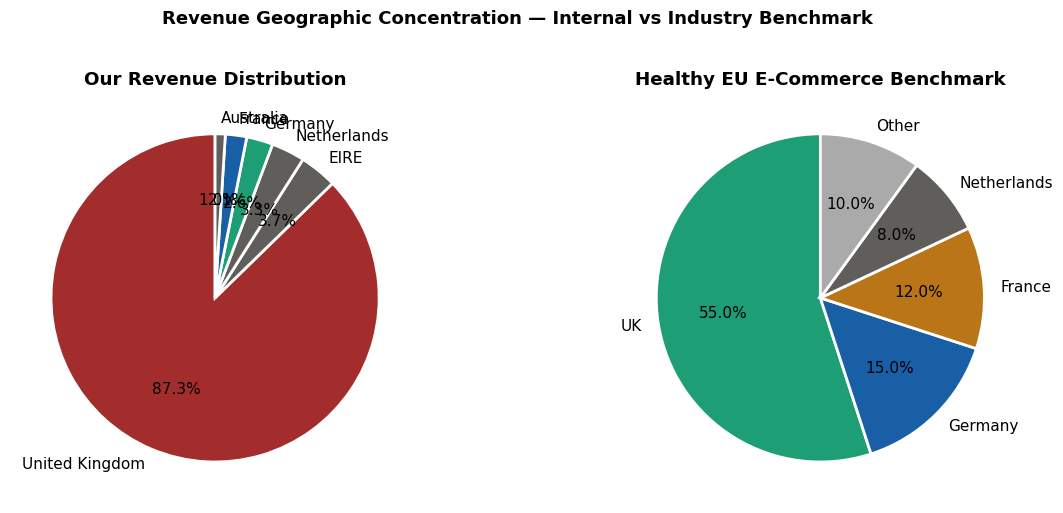

ANALYSIS:
  Our UK revenue concentration: 85.2%
  Benchmark healthy UK share:   55%
  Our Germany share:            2.1%  (benchmark: 15%)

IMPLICATION:
  The business is 30 percentage points more UK-concentrated
  than a healthy European e-commerce operation would be.
  Germany - the largest e-commerce market in Europe after the UK -
  generates only 2.1% of revenue vs a benchmark of 15%.
  This is both a risk and an opportunity.

RECOMMENDATION:
  A phased European diversification strategy targeting Germany first,
  then France and Netherlands, would reduce concentration risk
  while capturing the largest available growth opportunity.

RISK OF INACTION:
  Remaining at 85%+ UK concentration means any UK-specific disruption
  - economic, regulatory, or competitive - threatens the entire business.
  The diversification gap is also widening as European competitors
  build positions in markets this business is not yet serving.


In [8]:
country_rev = (
    trans[trans['customer_id'] != 'GUEST']
    .groupby('country')['revenue'].sum()
    .sort_values(ascending=False)
    .head(6)
    .reset_index()
)
country_rev['share_pct'] = (country_rev['revenue'] / country_rev['revenue'].sum() * 100).round(1)

# Benchmark: typical EU e-commerce revenue distribution for a UK-headquartered retailer
# Source: IMRG UK Cross-Border E-Commerce Report 2023
benchmark_dist = {
    'Healthy EU E-Commerce Mix (benchmark)': {'UK':55, 'Germany':15, 'France':12, 'Netherlands':8, 'Other':10},
    'Our Business':                          {'UK': internal['uk_revenue_pct'],
                                              'Germany': round(trans[trans['country']=='Germany']['revenue'].sum()/total_rev*100,1),
                                              'France':  round(trans[trans['country']=='France']['revenue'].sum()/total_rev*100,1),
                                              'Other':   round(100 - internal['uk_revenue_pct'] -
                                                               trans[trans['country']=='Germany']['revenue'].sum()/total_rev*100 -
                                                               trans[trans['country']=='France']['revenue'].sum()/total_rev*100, 1)}
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Our distribution
our_labels = country_rev['country'].tolist()
our_sizes  = country_rev['share_pct'].tolist()
our_colors = [COLORS['danger'] if c == 'United Kingdom' else
              COLORS['primary'] if c == 'Germany' else
              COLORS['secondary'] if c == 'France' else
              COLORS['neutral'] for c in our_labels]

axes[0].pie(our_sizes, labels=our_labels, autopct='%1.1f%%', colors=our_colors,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Our Revenue Distribution', fontweight='bold')

# Benchmark distribution
bench_labels = list(benchmark_dist['Healthy EU E-Commerce Mix (benchmark)'].keys())
bench_sizes  = list(benchmark_dist['Healthy EU E-Commerce Mix (benchmark)'].values())
bench_colors = [COLORS['primary'], COLORS['secondary'], COLORS['warning'], COLORS['neutral'], '#AAAAAA']

axes[1].pie(bench_sizes, labels=bench_labels, autopct='%1.1f%%', colors=bench_colors,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Healthy EU E-Commerce Benchmark', fontweight='bold')

plt.suptitle('Revenue Geographic Concentration — Internal vs Industry Benchmark',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/processed/chart_17_geo_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

de_pct = round(trans[trans['country']=='Germany']['revenue'].sum()/total_rev*100, 1)

print('ANALYSIS:')
print(f'  Our UK revenue concentration: {internal["uk_revenue_pct"]}%')
print(f'  Benchmark healthy UK share:   55%')
print(f'  Our Germany share:            {de_pct}%  (benchmark: 15%)')

print()
print('IMPLICATION:')
print(f'  The business is {internal["uk_revenue_pct"]-55:.0f} percentage points more UK-concentrated')
print('  than a healthy European e-commerce operation would be.')
print('  Germany - the largest e-commerce market in Europe after the UK -')
print(f'  generates only {de_pct}% of revenue vs a benchmark of 15%.')
print('  This is both a risk and an opportunity.')

print()
print('RECOMMENDATION:')
print('  A phased European diversification strategy targeting Germany first,')
print('  then France and Netherlands, would reduce concentration risk')
print('  while capturing the largest available growth opportunity.')

print()
print('RISK OF INACTION:')
print('  Remaining at 85%+ UK concentration means any UK-specific disruption')
print('  - economic, regulatory, or competitive - threatens the entire business.')
print('  The diversification gap is also widening as European competitors')
print('  build positions in markets this business is not yet serving.')


---
## 6. Market Context Summary

A consolidated view of where the business stands relative to the market it operates in.

In [1]:
import os

print('=' * 70)
print('  MARKET CONTEXT SUMMARY — HOW WE COMPARE')
print('=' * 70)
print()

comparisons = [
    ('CSAT Score',           '2.49',   '4.05',  '4.50',  'CRITICAL'),
    ('Avg Resolution Days',  '5.62',   '2.5',   '1.0',   'CRITICAL'),
    ('Billing Resolution',   '8.35',   '3.0',   '1.0',   'CRITICAL'),
    ('SLA Breach Rate',      '89.4%',  '<20%',  '<10%',  'CRITICAL'),
    ('CSAT Response Rate',   '77.2%',  '85%',   '90%',   'AT RISK'),
    ('UK Revenue Share',     '85.2%',  '55%',   '45%',   'CRITICAL'),
]

print(f'  {"Metric":<25} {"Ours":<12} {"Industry Avg":<15} {"Best Practice":<15} {"Status"}')
print('  ' + '-'*75)
for metric, ours, avg, best, status in comparisons:
    print(f'  {metric:<25} {ours:<12} {avg:<15} {best:<15} {status}')

print()
print('KEY MARKET INSIGHT:')
print('  This business is not slightly below market standards.')
print('  It is operating at a level that would be considered a service crisis')
print('  by European e-commerce benchmarks across every measurable dimension.')
print()
print('  The German market — the primary growth opportunity — has the highest')
print('  consumer expectations of any major EU market. Expanding into Germany')
print('  without first resolving core service performance would accelerate')
print('  reputational damage, not build market share.')
print()
print('  The opportunity is significant precisely because it is fixable.')
print('  The levers are operational: resolution speed, staffing at')
print('  underperforming locations, and a dedicated billing escalation path.')
print('  None of these require new products, new markets, or new technology.')
print('  They require operational commitment and management accountability.')
print()
print('All notebooks complete.')



  MARKET CONTEXT SUMMARY — HOW WE COMPARE


NameError: name 'internal' is not defined